**Exercise 6.1 — Card problem.**
You have 10 cards numbered from 1 to 10. You have to choose a way of dividing
them into two piles, so that the cards in the first pile sum to a number as close as
possible to 36, and the remaining cards in the other pile multiply to a number as
close as possible to 360.

Genotype encoding

Each card can be put in Pile_0 or Pile_1, there are 1024 possible ways of sorting
them into two piles, and you have to find the best. Think of a sensible way of
encoding any possible solution-attempt as a genotype.
Fitness
Some of these solution attempts will be closer to the target than others. Think
of a sensible way of evaluating any solution-attempt and scoring it with a fitness-
measure.

Assignment

Write a program to run a Genetic Algorithm with your genotype encoding and
fitness function. Run it once for a suitable (probably very large – you choose)
number of generations. Then repeat that same run a number of times (like, 100)
and see if you get the same answer each time, see how much variance there is
between each run

In [ ]:
#first i apply this procedure:
#*1 define population 
# 2 define its fitness function
# 3 select parent
#   we select only 0.2 fittest parents based on score
#   we cannot change the length of the individuals because of the cards pile rule
# 4 mutate or crossover
# 5 repeat from 3 until convergence
# random.seed(42)


In [1]:
import random
from functools import reduce
from operator import add
import matplotlib.pyplot as plt
import statistics
#here below i define the population andsimply apply a crossover & mutation
# population 
# genotype encode is very simple: - 1 for pile for the Sum search and 2 for product pile. 
#                                 - Each number position represent a decimal number
# phenotype is each pile
class Population:
    def __init__(self, pop_length: int):
        self.population = self.populate(pop_length)
    def populate(self, size):
        population = []
        for i in range(0, size):
            individual = []
            for card in range(10):
                state = random.randint(1,2)        
                individual.append(state)
            print(individual)
            population.append(individual)
        return population

    def evolve(self, fit_target=(36, 360), retain=0.2,
           random_select=0.07, mutate=0.01):
        eval_lst = [[inv,fitness(inv, target=fit_target)] for inv in self.population]
        #*choose 20% of best scored individuals
        
        # print(min(eval_lst, key=lambda x: x[1]))
        eval_lst = [x[0] for x in sorted(eval_lst, key=lambda x: x[1])]
        retain_length = int(retain * len(eval_lst))
        parents = eval_lst[:retain_length]
        #* choose arround 5% for diversity
        for individual in eval_lst[retain_length:]:
            if random_select > random.random():
                parents.append(individual)  
        #crossover
        children_desired_length = len(self.population) - len(parents)
    
        children = []
        while len(children) < children_desired_length:
            male = random.randint(0, len(parents)-1)
            female = random.randint(0, len(parents)-1)
            if male != female:
                male = parents[male]
                female = parents[female]
                half = int(len(male)/ 2)
                child = male[:half] + female[half:]
                children.append(child)
                # print("crossover done")
        #do mutations
        for indv in children:
            if mutate > random.random():
                rand_indx = random.randint(0, len(indv)-1)
                indv[rand_indx] = random.randint(1,2)
                # print("mutation done")
        parents.extend(children)
        self.population = parents
    def get_size(self):
        return len(self.population)
    


Now I define the a simple fitness function that helps us minimize our difference to the target values and some help functions for a neater code


In [3]:
def fitness( indv, target = (36, 360), get_all = False):
    sum = 0
    prod = 1
    for indx, card in enumerate(indv):
        indx += 1
        if card == 1:
            #sum
            sum += indx
        elif card == 2:
            prod *= indx
    fit_sum = abs(target[0] - sum)
    fit_prod = abs(target[1] - prod)
    av_fit = (fit_sum + fit_prod)/2
    if get_all:
        return av_fit, sum, prod 
    return av_fit
def grade(pop: Population, target=(36, 360)):
    fitness_all = [fitness(x, target) for x in pop.population]
    summed = reduce(add, fitness_all, 0)
    return summed/pop.get_size(), statistics.stdev(fitness_all)
def decode(gen, target):
    sum = 0
    prod = 1
    for indx, pile in enumerate(gen): 
        card = indx + 1
        if pile == 1:
            sum += card
        elif pile == 2:
            prod *= card
    return (sum, prod), target[0]-sum, target[1]-prod

Let's let it run and see what comes from the search space:

[2, 1, 1, 2, 2, 1, 2, 2, 2, 2]
[1, 1, 1, 1, 1, 1, 2, 2, 2, 2]
[1, 1, 1, 2, 1, 2, 2, 2, 1, 2]
[2, 2, 2, 1, 1, 2, 2, 2, 2, 1]
[1, 1, 2, 1, 2, 2, 1, 1, 1, 1]
[1, 2, 2, 2, 1, 1, 2, 2, 2, 2]
[1, 2, 1, 1, 1, 1, 2, 1, 2, 2]
[2, 1, 2, 1, 2, 2, 1, 1, 1, 2]
[2, 1, 1, 1, 2, 2, 1, 1, 2, 2]
[1, 1, 1, 1, 1, 1, 1, 2, 1, 2]
[1, 2, 1, 2, 2, 1, 1, 2, 1, 2]
[1, 2, 1, 1, 2, 2, 2, 2, 1, 2]
[2, 2, 2, 2, 2, 1, 2, 2, 1, 1]
[1, 1, 1, 2, 2, 1, 1, 2, 2, 1]
[2, 2, 2, 1, 2, 1, 1, 2, 1, 2]
[1, 2, 2, 1, 2, 2, 1, 1, 2, 1]
[2, 1, 1, 1, 1, 2, 2, 1, 2, 1]
[1, 1, 1, 1, 2, 2, 1, 2, 2, 2]
[1, 1, 1, 2, 1, 2, 1, 1, 1, 2]
[2, 2, 2, 2, 2, 2, 1, 2, 1, 2]
[2, 1, 1, 2, 1, 1, 2, 2, 2, 1]
[2, 2, 1, 2, 2, 1, 1, 1, 1, 2]
[2, 1, 1, 2, 2, 2, 2, 1, 1, 1]
[1, 1, 2, 2, 1, 1, 2, 1, 2, 2]
[2, 2, 2, 2, 1, 2, 1, 1, 1, 2]
[2, 2, 1, 1, 1, 1, 2, 1, 2, 2]
[1, 2, 1, 1, 1, 1, 2, 1, 2, 1]
[1, 2, 1, 1, 2, 1, 1, 1, 2, 1]
[1, 2, 2, 1, 2, 2, 2, 1, 2, 1]
[2, 1, 1, 2, 2, 1, 1, 2, 1, 1]
[1, 1, 2, 1, 2, 2, 1, 2, 1, 2]
[1, 2, 2, 2, 1, 1, 2, 1, 2, 1]
[1, 2, 2

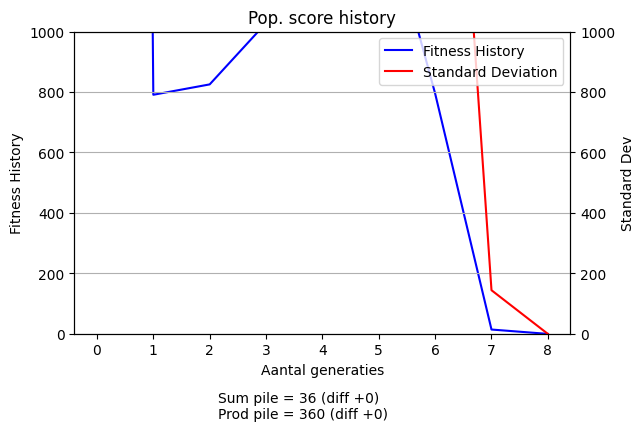

In [9]:
                
pop_target = (36, 360)
pop_length = 100
pop1 = Population(pop_length)
# pop1.populate(pop_length)
n_generations = 250
fitness_history = []
std_fitness = []
for _ in range(n_generations):
    pop1.evolve(fit_target=pop_target)
    score, stdev_fitness = grade(pop1, target=pop_target)
    fitness_history.append(score)
    std_fitness.append(stdev_fitness)

    #print(score, end=", ")
    if score < 0.05:
        break

best = min(pop1.population, key = lambda x: fitness(x))
best_score = fitness(best)
#print("\n Best individual: ",best, best_score) 
decoded_best_indv, sum_distance, prod_distance = decode(best, target=pop_target)
sum_pile = []
prod_pile = []
for indx, card in enumerate(best):
    if card == 1:
        sum_pile.append(indx+1)
    elif card == 2:
        prod_pile.append(indx+1)
print("Best phenotype as value: ", decoded_best_indv)

print("Best phenotype as piles: ", sum_pile, " | ", prod_pile )



pile_sum = sum(sum_pile)
pile_prod = 1
for value in prod_pile:
    pile_prod *= value
# differences from targets
diff_sum = pop_target[0] - pile_sum
diff_prod = pop_target[1] - pile_prod
label_text = (
    f"Sum pile = {pile_sum} (diff {diff_sum:+d})\n"
    f"Prod pile = {pile_prod} (diff {diff_prod:+d})"
)

fig, ax1 = plt.subplots()

line1 = ax1.plot(
    fitness_history,
    color="blue",
    label="Fitness History"
)

ax1.set_ylabel("Fitness History")
ax1.set_ylim(top=1000, bottom=0)
ax1.set_xlabel("Aantal generaties")

ax2 = ax1.twinx()

line2 = ax2.plot(
    std_fitness,
    color="red",
    label="Standard Deviation"
)

ax2.set_ylabel("Standard Dev")
ax2.set_ylim(top = 1000, bottom= 0)
# Combine both lines into one legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax2.legend(lines, labels, loc="upper right")

# leave room on the right for the label outside the axes
fig.subplots_adjust(bottom=0.25)
# place the label in figure coordinates to the right of the axes
fig.text(0.35,0.1, label_text, fontsize=10, va='center', ha='left', bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

plt.title("Pop. score history")

plt.grid(True)

plt.show()

As we can see the population starts with a high standard deviation value, which is normal at the beginning. But the population quickly converges to a very low distance to the average in the population. It is not perfect since it's works just as a search machine in a space of solutions. As we can see here below
![image](./many_generations.png)

But sometimes it can find the results very quick:
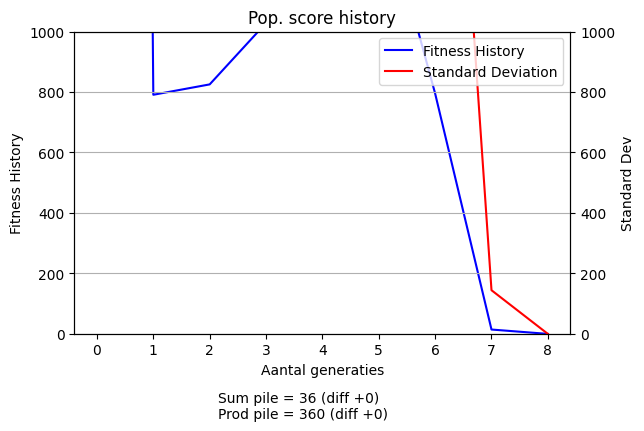